# 08 — XGBoost

Este notebook inicia XGBoost mediante búsquedas pequeñas y secuenciales. Primero compara la base depurada de 24 variables con la poda de 17; luego ejecuta una grilla de cuatro configuraciones sobre el conjunto ganador. Si el mejor resultado cae en un extremo, se agregará una segunda grilla local antes de consultar el holdout temporal.

En esta primera ejecución 2017 permanece reservado. Esta separación evita lanzar una búsqueda amplia y evita utilizar el holdout para orientar hiperparámetros.

## Imports y resolución de la raíz

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import RocCurveDisplay
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

pd.set_option("display.max_columns", None)

In [2]:
def find_project_root(start_path=None):
    """Busca la raíz del repositorio a partir del directorio actual."""
    start = Path(start_path or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "raw").is_dir() and (candidate / "src").is_dir():
            return candidate
    return None

PROJECT_ROOT = find_project_root()
if PROJECT_ROOT is None:
    raise FileNotFoundError("No se encontró la raíz local del proyecto.")
project_root_str = str(PROJECT_ROOT)
if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)
print(f"Raíz del proyecto: {PROJECT_ROOT}")

Raíz del proyecto: C:\Code\Vialesoft\Vialesoft_Devlab\Mini_Proyectos\Machine_Learning\Obligatorio2026


In [3]:
from src.config import RANDOM_STATE, RAW_DATA_DIR
from src.data import (
    combine_hotel_datasets,
    load_csv_with_fallback,
    make_temporal_holdout_split,
    normalize_text_values,
)
from src.evaluation import (
    cross_validate_model,
    evaluate_binary_classifier,
    get_grid_results,
    get_stratified_group_cross_validation,
    run_grid_search,
)
from src.features import (
    build_base_feature_set,
    build_tree_model_feature_sets,
    get_feature_types,
    make_exact_feature_groups,
)
from src.plots import plot_confusion_matrix
from src.preprocessing import build_tabular_preprocessor

## Carga, conjuntos y desarrollo temporal

In [4]:
H1_URL = "https://raw.githubusercontent.com/Lithium582/Obligatorio2026/refs/heads/main/data/raw/H1.csv"
H2_URL = "https://raw.githubusercontent.com/Lithium582/Obligatorio2026/refs/heads/main/data/raw/H2.csv"

h1_df = load_csv_with_fallback(RAW_DATA_DIR / "H1.csv", H1_URL)
h2_df = load_csv_with_fallback(RAW_DATA_DIR / "H2.csv", H2_URL)
bookings_df = normalize_text_values(combine_hotel_datasets(h1_df, h2_df))
X_reference, y = build_base_feature_set(bookings_df)
xgboost_feature_sets = build_tree_model_feature_sets(X_reference)

X_reference_train, X_reference_holdout, y_train, y_holdout = make_temporal_holdout_split(
    X_reference,
    y,
    period_values=X_reference["ArrivalDateYear"],
    validation_period=2017,
)
feature_sets_train = {
    name: frame.loc[X_reference_train.index].copy()
    for name, frame in xgboost_feature_sets.items()
}
feature_sets_holdout = {
    name: frame.loc[X_reference_holdout.index].copy()
    for name, frame in xgboost_feature_sets.items()
}
PRUNED_SET_NAME = "Tree-pruned | 17 features"
comparison_groups = make_exact_feature_groups(feature_sets_train[PRUNED_SET_NAME])

display(pd.DataFrame([
    {
        "feature_set": name,
        "feature_count": frame.shape[1],
        "development_rows": len(frame),
        "holdout_rows_reserved": len(feature_sets_holdout[name]),
    }
    for name, frame in feature_sets_train.items()
]))

,feature_set,feature_count,development_rows,holdout_rows_reserved
0,Cleaned base | 24 features,24,78703,40687
1,Tree-pruned | 17 features,17,78703,40687


## Pipeline y configuración fija

XGBoost utiliza `tree_method="hist"` para acelerar el entrenamiento. El paralelismo se administra desde la validación cruzada y cada estimador trabaja con un único hilo. `scale_pos_weight` se calcula exclusivamente sobre desarrollo.

In [5]:
negative_count = y_train.eq(0).sum()
positive_count = y_train.eq(1).sum()
development_scale_pos_weight = negative_count / positive_count


def build_xgboost_pipeline(X, **model_parameters):
    numeric_features, categorical_features = get_feature_types(
        X, require_all_categorical=False
    )
    preprocessor = build_tabular_preprocessor(
        numeric_features=numeric_features,
        categorical_features=categorical_features,
        scale_numeric=False,
    )
    default_parameters = {
        "n_estimators": 150,
        "learning_rate": 0.08,
        "max_depth": 4,
        "min_child_weight": 5,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "reg_alpha": 0.0,
        "reg_lambda": 5.0,
        "scale_pos_weight": development_scale_pos_weight,
        "objective": "binary:logistic",
        "eval_metric": "auc",
        "tree_method": "hist",
        "n_jobs": 1,
        "random_state": RANDOM_STATE,
    }
    default_parameters.update(model_parameters)
    return Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(**default_parameters)),
    ])

print(f"scale_pos_weight de desarrollo: {development_scale_pos_weight:.4f}")

scale_pos_weight de desarrollo: 1.7635


## Comparación de los conjuntos

Ambos conjuntos se evalúan con la misma configuración fija y los grupos calculados sobre la poda. Esta etapa requiere diez ajustes de 150 boosting rounds.

In [6]:
feature_set_records = []
feature_set_fold_records = []
for feature_set_name, X_candidate in feature_sets_train.items():
    comparison_cv = get_stratified_group_cross_validation(n_splits=5)
    scores = cross_validate_model(
        estimator=build_xgboost_pipeline(X_candidate),
        X=X_candidate,
        y=y_train,
        scoring="roc_auc",
        cv=comparison_cv,
        groups=comparison_groups,
        n_jobs=-1,
    )
    feature_set_records.append({
        "feature_set": feature_set_name,
        "feature_count": X_candidate.shape[1],
        "cv_roc_auc_mean": scores.mean(),
        "cv_roc_auc_std": scores.std(),
    })
    feature_set_fold_records.extend([
        {"feature_set": feature_set_name, "fold": fold, "roc_auc": score}
        for fold, score in enumerate(scores, start=1)
    ])

feature_set_results = pd.DataFrame(feature_set_records).sort_values(
    "cv_roc_auc_mean", ascending=False
).reset_index(drop=True)
cleaned_base_score = feature_set_results.loc[
    feature_set_results["feature_set"].eq("Cleaned base | 24 features"),
    "cv_roc_auc_mean",
].iloc[0]
feature_set_results["delta_vs_cleaned_base"] = (
    feature_set_results["cv_roc_auc_mean"] - cleaned_base_score
)
feature_set_fold_results = pd.DataFrame(feature_set_fold_records)
selected_feature_set_name = feature_set_results.iloc[0]["feature_set"]
display(feature_set_results.round(6))
display(feature_set_fold_results.pivot(
    index="fold", columns="feature_set", values="roc_auc"
).round(6))
print(f"Conjunto seleccionado: {selected_feature_set_name}")

,feature_set,feature_count,cv_roc_auc_mean,cv_roc_auc_std,delta_vs_cleaned_base
0,Tree-pruned | 17 features,17,0.930047,0.002319,0.000044
1,Cleaned base | 24 features,24,0.930003,0.002273,0.000000


feature_set,Cleaned base | 24 features,Tree-pruned | 17 features
fold,,
1,0.925670,0.926055
2,0.929851,0.930067
3,0.931960,0.933035
4,0.931303,0.931419
5,0.931230,0.929659


Conjunto seleccionado: Tree-pruned | 17 features


## Grilla 1 — complejidad local

La primera grilla varía únicamente profundidad y peso mínimo de los hijos. Son cuatro configuraciones, 20 ajustes y 150 boosting rounds por ajuste. `learning_rate`, muestreo y regularización permanecen fijos. Los resultados indicarán si hace falta desplazar alguno de los rangos.

In [7]:
X_selected_train = feature_sets_train[selected_feature_set_name]
X_selected_holdout = feature_sets_holdout[selected_feature_set_name]
xgboost_stage_one_pipeline = build_xgboost_pipeline(X_selected_train)
xgboost_stage_one_param_grid = {
    "model__max_depth": [3, 5],
    "model__min_child_weight": [5, 15],
}
stage_one_grid_size = np.prod([len(values) for values in xgboost_stage_one_param_grid.values()])
print(
    f"Grilla 1: {stage_one_grid_size} configuraciones, "
    f"{stage_one_grid_size * 5} ajustes y 150 boosting rounds por ajuste."
)

Grilla 1: 4 configuraciones, 20 ajustes y 150 boosting rounds por ajuste.


In [8]:
stage_one_cv = get_stratified_group_cross_validation(n_splits=5)
xgboost_stage_one_search = run_grid_search(
    estimator=xgboost_stage_one_pipeline,
    param_grid=xgboost_stage_one_param_grid,
    X=X_selected_train,
    y=y_train,
    scoring="roc_auc",
    cv=stage_one_cv,
    groups=comparison_groups,
    n_jobs=-1,
)
stage_one_results = get_grid_results(xgboost_stage_one_search)
stage_one_results["train_validation_gap"] = (
    stage_one_results["mean_train_score"] - stage_one_results["mean_test_score"]
)
stage_one_columns = [
    "params", "mean_train_score", "mean_test_score",
    "std_test_score", "train_validation_gap", "rank_test_score",
]
display(stage_one_results[stage_one_columns].round(6))
print(f"Mejores parámetros: {xgboost_stage_one_search.best_params_}")
print(f"Mejor ROC AUC CV: {xgboost_stage_one_search.best_score_:.6f}")

,params,mean_train_score,mean_test_score,std_test_score,train_validation_gap,rank_test_score
0,"{'model__max_depth': 5, 'model__min_child_weig...",0.943067,0.933626,0.002311,0.009441,1
1,"{'model__max_depth': 5, 'model__min_child_weig...",0.942103,0.933595,0.002388,0.008508,2
2,"{'model__max_depth': 3, 'model__min_child_weig...",0.929616,0.924744,0.003325,0.004871,3
3,"{'model__max_depth': 3, 'model__min_child_weig...",0.929320,0.924356,0.003108,0.004964,4


Mejores parámetros: {'model__max_depth': 5, 'model__min_child_weight': 5}
Mejor ROC AUC CV: 0.933626


## Grilla 2 — extensión de profundidad

La primera grilla eligió `max_depth=5`, el extremo superior. `min_child_weight=5` superó a 15 por sólo 0,000031 de ROC AUC, mientras que 15 presentó menor gap train–CV; no existe evidencia para explorar valores menos regularizados. La segunda grilla agrega únicamente profundidad 7 con ambos pesos, evitando repetir las configuraciones ya entrenadas. Son dos configuraciones y diez ajustes.

In [9]:
xgboost_stage_two_pipeline = build_xgboost_pipeline(X_selected_train)
xgboost_stage_two_param_grid = {
    "model__max_depth": [7],
    "model__min_child_weight": [5, 15],
}
stage_two_grid_size = np.prod([len(values) for values in xgboost_stage_two_param_grid.values()])
print(
    f"Grilla 2: {stage_two_grid_size} configuraciones, "
    f"{stage_two_grid_size * 5} ajustes y 150 boosting rounds por ajuste."
)

Grilla 2: 2 configuraciones, 10 ajustes y 150 boosting rounds por ajuste.


In [10]:
stage_two_cv = get_stratified_group_cross_validation(n_splits=5)
xgboost_stage_two_search = run_grid_search(
    estimator=xgboost_stage_two_pipeline,
    param_grid=xgboost_stage_two_param_grid,
    X=X_selected_train,
    y=y_train,
    scoring="roc_auc",
    cv=stage_two_cv,
    groups=comparison_groups,
    n_jobs=-1,
)
stage_two_results = get_grid_results(xgboost_stage_two_search)
stage_two_results["train_validation_gap"] = (
    stage_two_results["mean_train_score"] - stage_two_results["mean_test_score"]
)
display(stage_two_results[stage_one_columns].round(6))
print(f"Mejores parámetros de grilla 2: {xgboost_stage_two_search.best_params_}")
print(f"Mejor ROC AUC CV de grilla 2: {xgboost_stage_two_search.best_score_:.6f}")

,params,mean_train_score,mean_test_score,std_test_score,train_validation_gap,rank_test_score
0,"{'model__max_depth': 7, 'model__min_child_weig...",0.952848,0.938565,0.002763,0.014283,1
1,"{'model__max_depth': 7, 'model__min_child_weig...",0.951362,0.938277,0.002909,0.013085,2


Mejores parámetros de grilla 2: {'model__max_depth': 7, 'model__min_child_weight': 5}
Mejor ROC AUC CV de grilla 2: 0.938565


In [11]:
combined_search_results = pd.concat([
    stage_one_results.assign(search_stage="Grid 1"),
    stage_two_results.assign(search_stage="Grid 2"),
], ignore_index=True).sort_values("mean_test_score", ascending=False).reset_index(drop=True)
display(combined_search_results[["search_stage", *stage_one_columns]].round(6))

selected_xgboost_params = {
    "model__max_depth": 7,
    "model__min_child_weight": 15,
}
selected_candidate_mask = combined_search_results["params"].apply(
    lambda params: all(params[key] == value for key, value in selected_xgboost_params.items())
)
selected_candidate = combined_search_results.loc[selected_candidate_mask].iloc[0]
selected_xgboost_cv_score = selected_candidate["mean_test_score"]
selected_xgboost_cv_std = selected_candidate["std_test_score"]
selected_xgboost_train_score = selected_candidate["mean_train_score"]

print("Selección regularizada: Grid 2")
print(f"Parámetros seleccionados: {selected_xgboost_params}")
print(f"ROC AUC CV seleccionado: {selected_xgboost_cv_score:.6f}")
print(f"Gap train–CV seleccionado: {selected_xgboost_train_score - selected_xgboost_cv_score:.6f}")

,search_stage,params,mean_train_score,mean_test_score,std_test_score,train_validation_gap,rank_test_score
0,Grid 2,"{'model__max_depth': 7, 'model__min_child_weig...",0.952848,0.938565,0.002763,0.014283,1
1,Grid 2,"{'model__max_depth': 7, 'model__min_child_weig...",0.951362,0.938277,0.002909,0.013085,2
2,Grid 1,"{'model__max_depth': 5, 'model__min_child_weig...",0.943067,0.933626,0.002311,0.009441,1
3,Grid 1,"{'model__max_depth': 5, 'model__min_child_weig...",0.942103,0.933595,0.002388,0.008508,2
4,Grid 1,"{'model__max_depth': 3, 'model__min_child_weig...",0.929616,0.924744,0.003325,0.004871,3
5,Grid 1,"{'model__max_depth': 3, 'model__min_child_weig...",0.929320,0.924356,0.003108,0.004964,4


Selección regularizada: Grid 2
Parámetros seleccionados: {'model__max_depth': 7, 'model__min_child_weight': 15}
ROC AUC CV seleccionado: 0.938277
Gap train–CV seleccionado: 0.013085


## Decisión de hiperparámetros

Profundidad 7 mejora aproximadamente 0,005 de ROC AUC respecto a profundidad 5. Dentro de profundidad 7, `min_child_weight=5` alcanza 0,938565 y peso 15 alcanza 0,938277. La diferencia de 0,000288 es pequeña frente a la desviación entre folds, mientras que peso 15 reduce el gap train–CV de 0,014283 a 0,013085. Se selecciona por tanto `max_depth=7` y `min_child_weight=15` antes de consultar el holdout.

## Evaluación única sobre el holdout temporal

El candidato regularizado se reajusta sobre todo 2015–2016 y se evalúa una sola vez sobre enero–agosto de 2017. El threshold permanece en 0,5 para comparar Accuracy, Precision, Recall y F1. El resultado temporal no se utilizará para una nueva búsqueda.

In [12]:
final_xgboost_model = build_xgboost_pipeline(
    X_selected_train,
    max_depth=7,
    min_child_weight=15,
)
final_xgboost_model.fit(X_selected_train, y_train)
xgboost_metrics = evaluate_binary_classifier(
    final_xgboost_model, X_selected_holdout, y_holdout, threshold=0.5
)

In [13]:
technical_comparison = pd.DataFrame([
    {
        "model": "Logistic Regression engineered",
        "cv_roc_auc": 0.908557, "holdout_roc_auc": 0.855017,
        "accuracy": 0.739032, "precision": 0.620290,
        "recall": 0.839568, "f1": 0.713461,
    },
    {
        "model": "Decision Tree pruned",
        "cv_roc_auc": 0.927092, "holdout_roc_auc": 0.838694,
        "accuracy": 0.765822, "precision": 0.723456,
        "recall": 0.639187, "f1": 0.678716,
    },
    {
        "model": "Random Forest",
        "cv_roc_auc": 0.941260, "holdout_roc_auc": 0.842641,
        "accuracy": 0.769312, "precision": 0.748885,
        "recall": 0.607621, "f1": 0.670898,
    },
    {
        "model": "XGBoost regularized",
        "cv_roc_auc": selected_xgboost_cv_score,
        "holdout_roc_auc": xgboost_metrics["roc_auc"],
        "accuracy": xgboost_metrics["accuracy"],
        "precision": xgboost_metrics["precision"],
        "recall": xgboost_metrics["recall"],
        "f1": xgboost_metrics["f1"],
    },
]).set_index("model")
display(technical_comparison.round(6))
print(f"Gap CV–holdout: {selected_xgboost_cv_score - xgboost_metrics['roc_auc']:.6f}")

,cv_roc_auc,holdout_roc_auc,accuracy,precision,recall,f1
model,,,,,,
Logistic Regression engineered,0.908557,0.855017,0.739032,0.620290,0.839568,0.713461
Decision Tree pruned,0.927092,0.838694,0.765822,0.723456,0.639187,0.678716
Random Forest,0.941260,0.842641,0.769312,0.748885,0.607621,0.670898
XGBoost regularized,0.938277,0.867291,0.781724,0.737476,0.676913,0.705898


Gap CV–holdout: 0.070986


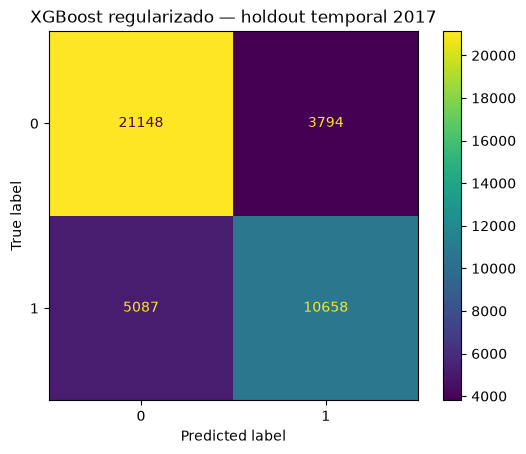

In [14]:
plot_confusion_matrix(
    final_xgboost_model, X_selected_holdout, y_holdout, threshold=0.5,
    title="XGBoost regularizado — holdout temporal 2017",
)

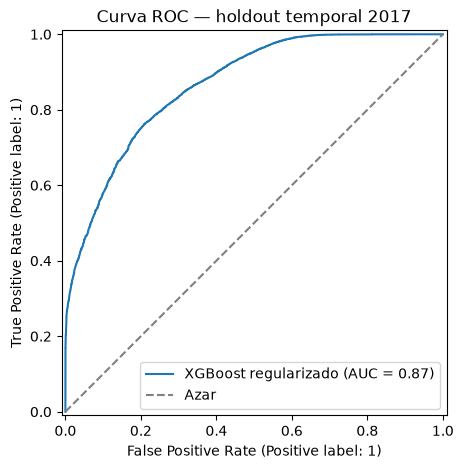

In [15]:
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_estimator(
    final_xgboost_model, X_selected_holdout, y_holdout,
    name="XGBoost regularizado", ax=ax,
)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Azar")
ax.set_title("Curva ROC — holdout temporal 2017")
ax.legend(loc="lower right")
plt.show()

## Importancia agregada del modelo final

Las importancias de las columnas transformadas se agrupan por variable original. Se presentan como descripción del modelo ya cerrado y no para realizar nuevas selecciones después de consultar 2017.

,source_feature,importance
3,Country,0.306326
10,MarketSegment,0.151825
12,PreviousCancellations,0.093485
4,CustomerType,0.087611
1,ArrivalDateMonth,0.078242
13,RequiredCarParkingSpaces,0.068560
16,TotalOfSpecialRequests,0.051124
6,DistributionChannel,0.047179
2,ArrivalDateYear,0.028773
9,LeadTime,0.022252


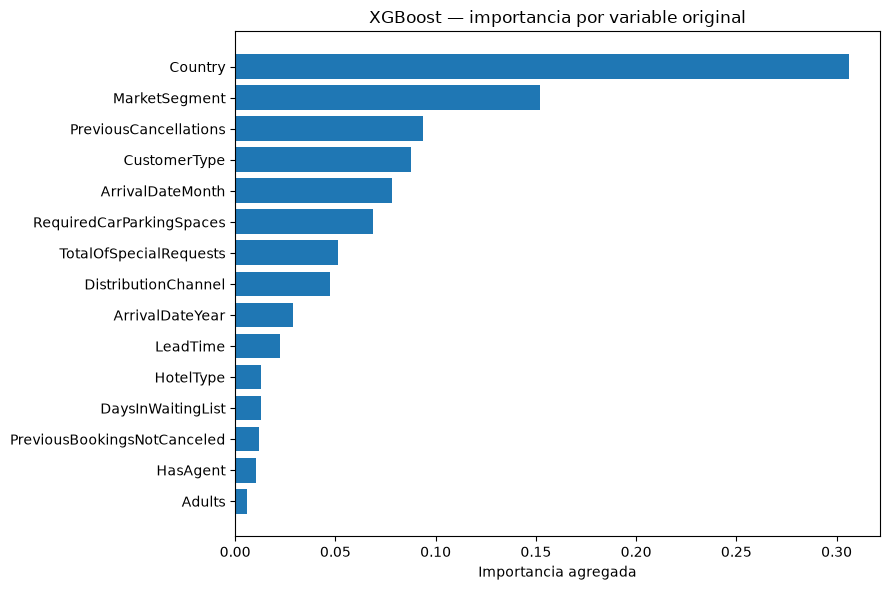

In [16]:
xgb_preprocessor = final_xgboost_model.named_steps["preprocessor"]
xgb_classifier = final_xgboost_model.named_steps["model"]
xgb_transformed_names = xgb_preprocessor.get_feature_names_out()
xgb_numeric_features, xgb_categorical_features = get_feature_types(
    X_selected_train, require_all_categorical=False
)
xgb_source_features = [*xgb_numeric_features]
xgb_onehot = xgb_preprocessor.named_transformers_["categorical"].named_steps["onehot"]
for feature, categories in zip(xgb_categorical_features, xgb_onehot.categories_):
    xgb_source_features.extend([feature] * len(categories))
if len(xgb_source_features) != len(xgb_transformed_names):
    raise ValueError("No se pudo reconstruir el origen de las columnas transformadas.")

xgb_transformed_importance = pd.DataFrame({
    "transformed_feature": xgb_transformed_names,
    "source_feature": xgb_source_features,
    "importance": xgb_classifier.feature_importances_,
})
xgb_importance = (
    xgb_transformed_importance
    .groupby("source_feature", as_index=False)["importance"].sum()
    .sort_values("importance", ascending=False)
)
display(xgb_importance.round(6))

plot_importance = xgb_importance.head(15).sort_values("importance")
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(plot_importance["source_feature"], plot_importance["importance"])
ax.set_xlabel("Importancia agregada")
ax.set_title("XGBoost — importancia por variable original")
plt.tight_layout()
plt.show()

## Conclusiones

La comparación de hiperparámetros se cerró antes de consultar 2017. Aunque `max_depth=7` y `min_child_weight=5` obtuvo la mayor media de CV (0,938565), se seleccionó `min_child_weight=15`: cedió solamente 0,000288 y redujo el gap train–CV de 0,014283 a 0,013085.

El modelo regularizado alcanzó ROC AUC CV 0,938277 y ROC AUC 0,867291 sobre el holdout temporal. Con threshold 0,5 obtuvo Accuracy 0,781724, Precision 0,737476, Recall 0,676913 y F1 0,705898. Es el mayor ROC AUC temporal y la mayor Accuracy obtenidos hasta esta etapa, con un equilibrio entre Precision y Recall superior al de los otros modelos basados en árboles.

El gap CV–2017 fue 0,070986: existe deterioro temporal, pero es menor que en Decision Tree y Random Forest. Logistic Regression conserva el mayor Recall (0,839568) y un F1 apenas superior (0,713461). La comparación operativa posterior se realizó a igual capacidad, sin seleccionar un threshold a partir del holdout.

Las importancias internas estuvieron dominadas por `Country`, `MarketSegment`, `PreviousCancellations`, `CustomerType`, `ArrivalDateMonth` y `RequiredCarParkingSpaces`. Se interpretan como aporte predictivo dentro de este modelo, no como efectos causales ni como una jerarquía independiente de la cardinalidad y las posibles divisiones de cada predictor.
